## Задание
Написать скрипт, который позволяет загружать изображение. Проводить сегментацию на указанное количество участков (используя метод кластеризации), а затем выводит изображение с полученными участками, а также участки исходного изображения, к которым применили отдельный сегмент как маску.

### Теория
Сегментация изображений -- процесс разбиения изображения на однородные, осмысленные регионы. Позволяет выделять на изображении объекты и анализировать структуру изображений.

### Выполнение работы

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans


IMAGE_PATH = "cat.jpg"
N_CLUSTERS = 3

Сначала изображение загружается с помощью `plt.imshow(image_path)`.

Original image size: (5481, 4385, 3)


(np.float64(-0.5), np.float64(4384.5), np.float64(5480.5), np.float64(-0.5))

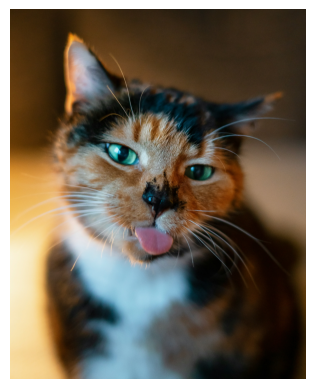

In [ ]:
image = plt.imread(IMAGE_PATH)
print(f"Original image size: {image.shape}")
plt.imshow(image)
plt.axis('off')

Размер изображения изменяется с помощью `np.reshape()`, чтобы подготовить данные для кластеризации и проводится кластеризация с помощью `sklearn.cluster.KMeans.fit()`.

In [ ]:
X = np.reshape(image, (-1, 3))
print(f"Reshaped image size: {X.shape}")

kmeans = KMeans(n_clusters=N_CLUSTERS)
kmeans.fit(X)

Reshaped image size: (24034185, 3)


KMeans(n_clusters=3)

После обучения модели KMeans на изображении берутся цвета из середины каждого кластера и применяются к всем пикселям соответствующих кластеров. Также цвета приводятся к `np.uint8`, чтобы далее корректно работали функции `opencv`.

(np.float64(-0.5), np.float64(4384.5), np.float64(5480.5), np.float64(-0.5))

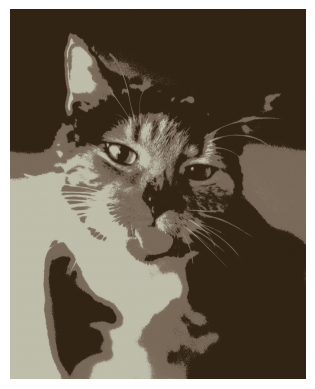

In [ ]:
segmented_image = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8).reshape(image.shape)
plt.imshow(segmented_image / 255)
plt.axis('off')

Сначала для каждого кластера находится бинарная маска. Далее с помощью `opencv` для каждого кластера строятся границы.

(np.float64(-0.5), np.float64(4384.5), np.float64(5480.5), np.float64(-0.5))

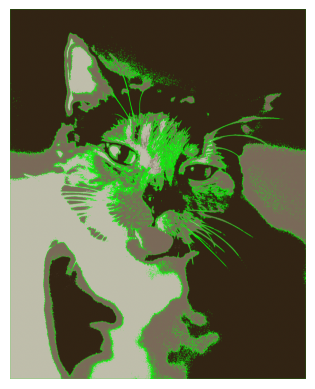

In [ ]:
# Draw borders around each cluster

import cv2

h, w, _ = image.shape
labels_2d = kmeans.labels_.reshape(h, w)

masks = []
for cluster_id in range(kmeans.n_clusters):
    # Create binary mask for current cluster
    mask = (labels_2d == cluster_id).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)

    cv2.drawContours(segmented_image, contours, -1, (0, 255, 0), 2)
    masks.append(mask)

plt.imshow(segmented_image / 255)
plt.axis('off')

Для визуализации бинарных масок строится решётка графиков, где в каждой клетке представлена визуализация бинарной маски для отдельного кластера. Сетка строится с помощью `plt.subplots`. Размеры сетки вычисляются динамически, количество столбцов всегда равно 3, а количество строк вычисляется динамически на основе количества кластеров.

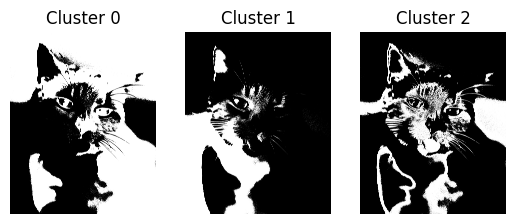

In [ ]:
# Visualize binary masks

i_w = 3
i_h = (len(masks) + i_w - 1) // i_w

fig, axs = plt.subplots(i_h, i_w)
if i_h == 1:
    axs = np.array([axs])
elif i_w == 1:
    axs = axs.reshape(-1, 1)

for i in range(i_h):
    for j in range(i_w):
        id = i_w * i + j
        if id >= len(masks):
            break
        axs[i][j].imshow(masks[id] / 255, cmap='gray')
        axs[i][j].set_title(f'Cluster {id}')
        axs[i][j].axis('off')

plt.show()

Ниже представлена визуализация исходных цветов отдельного кластера. Визуализируемые кластеры задаются в списке `CLUSTERS_TO_SHOW`.

(np.float64(-0.5), np.float64(4384.5), np.float64(5480.5), np.float64(-0.5))

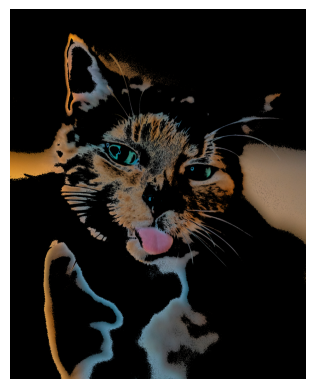

In [ ]:
CLUSTERS_TO_SHOW = [2]

mask = np.isin(kmeans.labels_, CLUSTERS_TO_SHOW)
masked_image = np.where(mask[:, None], X, 0).reshape(image.shape)
plt.imshow(masked_image / 255)
plt.axis('off')